In [15]:
# 상권 매출을 시각화 해서 비교
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd
from scipy import stats

df = pd.read_csv("../data/07-8_seoul_market_sales.csv")
df.head(3)



,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
2,20254,전통시장,노량진중앙시장,커피-음료,143339677,43869,95844027,47495650,84490667,57487331,2121862,42653948,43692418,15772423,24945022,12792323


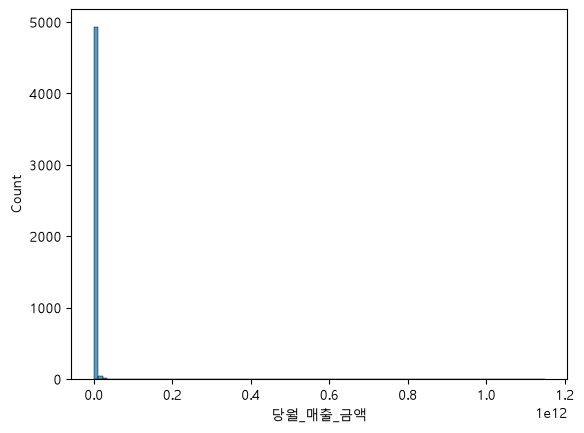

In [16]:

import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기본 폰트인 맑은 고딕 사용)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


sns.histplot(df['당월_매출_금액'], bins=100)
plt.show()

In [10]:
df[(df['당월_매출_금액'] > 148000000 )]

,기준_년분기_코드,상권_구분_코드_명,상권_코드_명,서비스_업종_코드_명,당월_매출_금액,당월_매출_건수,주중_매출_금액,주말_매출_금액,남성_매출_금액,여성_매출_금액,연령대_10_매출_금액,연령대_20_매출_금액,연령대_30_매출_금액,연령대_40_매출_금액,연령대_50_매출_금액,연령대_60_이상_매출_금액
0,20254,발달상권,"신촌역(신촌역, 신촌로터리)",스포츠 강습,190574012,563,185879107,4694905,62004846,122818273,1578072,62149177,70583498,12783010,35309971,2419391
1,20254,전통시장,동화동 골목형상점가,미용실,241121913,7596,158201210,82920703,110263603,126565631,689103,17374758,40986830,66989251,63290864,47498428
4,20254,발달상권,가산디지털단지,한식음식점,38845970041,1458137,34858600092,3987369949,16401281607,9491707466,78552880,4244996087,8066632051,6146656007,4798277628,2557874422
5,20254,관광특구,이태원 관광특구,가방,1090502870,5547,885896795,204606075,190536741,828948123,576954,98028433,104265999,303824723,232953614,279835141
6,20254,전통시장,도화동 상점가,스포츠클럽,190680256,178,158605126,32075130,90001177,67283290,0,0,50383455,18893895,76737074,11270043
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4992,20254,전통시장,능동로골목시장,한식음식점,1553210859,30993,1045977200,507233659,891603046,421916335,1306000,136579041,259821116,218927933,320294505,376590791
4995,20254,골목상권,대흥역 3번,외국어학원,513452201,875,513452201,0,307588052,205864149,0,0,123675359,361874370,7133806,20768666
4996,20254,발달상권,압구정역,시계및귀금속,180552179,343,127936320,52615859,59250788,121301391,15000000,65525084,30647697,18279843,18484315,32615240
4997,20254,발달상권,서대문역,의약품,4510690414,130126,4325172800,185517614,2414216413,2096474001,2763173,148048566,380214304,746846063,1152262468,2080555840


In [ ]:
# 관광특구의 당월 매출
tourism = df[df['상권_구분_코드_명'] == "관광특구"]["당월_매출_금액"]
tourism

In [ ]:
# 골목상권의 당월 매출
street = df[df['상권_구분_코드_명'] == "골목상권"]["당월_매출_금액"]
street 

In [17]:
print("관광특구 중앙값", tourism.median())
print("골목상권 중앙값", street.median())

관광특구 중앙값 1039448928.5
골목상권 중앙값 101829029.5


In [18]:
u, p = stats.mannwhitneyu(tourism, street)

print("p-value", f"{p:6f}")
print("u",u)

p-value 0.000000
u 92865.0


### 2. Wilcoxon
- 대응하는 두조건을 검증(대응 t검정 대안)
- 같은 상권의 주중 매출과 주말 매출이 다를까?
- 같은 상권이니까 -> 대응 t검정을 해야 하는데, 데이터가 치우쳐져 있으니 -> 비모수 검정

In [19]:
w, p = stats.wilcoxon(df['주중_매출_금액'],df['주말_매출_금액'])
print("p-value", f"{p:6f}")

p-value 0.000000


In [21]:
groups = []

for name, g in df.groupby("상권_구분_코드_명"):
    #print(name, g)
    groups.append(g['당월_매출_금액'].values)


h, p = stats.kruskal(*groups)
print("통계량", h)
print("p-value", f"{p:6f}")

통계량 454.1409256281272
p-value 0.000000
